# FIFA World Cup Prediction Model
## Notebook 03 — Model Training & Evaluation

**Goal:** Train all four models, evaluate them individually and as an ensemble, then save the final model for use in the tournament simulation.

### Model stack
| Model | Type | Predicts |
|---|---|---|
| Poisson Regression | Statistical | Expected goals → win/draw/loss probs |
| XGBoost | Gradient boosting | Win / draw / loss directly |
| Random Forest | Ensemble tree | Win / draw / loss directly |
| Logistic Regression | Linear baseline | Win / draw / loss directly |
| **Ensemble** | Weighted average | Final predictions |


In [2]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

from src.utils import data_path, model_path, output_path
from src.features import FEATURE_COLS, TARGET_OUTCOME, TARGET_HOME_GLS, TARGET_AWAY_GLS
from src.model import (
    PoissonMatchModel,
    build_xgboost, build_random_forest, build_logistic,
    EnsembleModel, evaluate_model, cross_validate_model
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

os.makedirs(os.path.join('..', 'models'), exist_ok=True)
os.makedirs(os.path.join('..', 'outputs'), exist_ok=True)

print('Imports OK ✓')


Imports OK ✓


## 1. Load feature matrix

In [3]:
features = pd.read_csv(
    os.path.join('..', 'data', 'processed', 'features.csv'),
    parse_dates=['date']
).sort_values('date').reset_index(drop=True)

print(f'Loaded {len(features):,} rows × {len(features.columns)} columns')
print(f'Date range: {features.date.min().date()} → {features.date.max().date()}')
print()
print('Outcome distribution:')
print(features[TARGET_OUTCOME].map({2:'home win', 1:'draw', 0:'away win'}).value_counts())


Loaded 32,287 rows × 28 columns
Date range: 1990-01-12 → 2026-06-10

Outcome distribution:
outcome
home win    15652
away win     9045
draw         7590
Name: count, dtype: int64


## 2. Train / test split

We use a **temporal split** — train on everything before 2018, test on 2018 onwards.
This mimics real-world usage: you train on past tournaments and predict future ones.
Never use random splits for time-series data.


In [4]:
SPLIT_DATE = '2018-01-01'

train = features[features.date < SPLIT_DATE].copy()
test  = features[features.date >= SPLIT_DATE].copy()

X_train = train[FEATURE_COLS]
X_test  = test[FEATURE_COLS]

y_train         = train[TARGET_OUTCOME]
y_test          = test[TARGET_OUTCOME]
y_train_home_g  = train[TARGET_HOME_GLS]
y_train_away_g  = train[TARGET_AWAY_GLS]

print(f'Train: {len(train):,} matches  ({train.date.min().date()} → {train.date.max().date()})')
print(f'Test:  {len(test):,}  matches  ({test.date.min().date()}  → {test.date.max().date()})')
print()
print('Train outcome distribution:')
print(y_train.map({2:'home win', 1:'draw', 0:'away win'}).value_counts())


Train: 24,179 matches  (1990-01-12 → 2017-12-29)
Test:  8,108  matches  (2018-01-02  → 2026-06-10)

Train outcome distribution:
outcome
home win    11778
away win     6680
draw         5721
Name: count, dtype: int64


## 3. Train all models

In [5]:
# 3a. Poisson model
print('Training Poisson model...')
poisson_model = PoissonMatchModel(max_goals=10)
poisson_model.fit(X_train, y_train_home_g, y_train_away_g)
print('  Done ✓')


Training Poisson model...
  Done ✓


In [6]:
# 3b. XGBoost
print('Training XGBoost...')
xgb_model = build_xgboost(n_estimators=400, learning_rate=0.05)
xgb_model.fit(X_train, y_train)
print('  Done ✓')


Training XGBoost...
  Done ✓


In [7]:
# 3c. Random Forest
print('Training Random Forest (500 trees)...')
rf_model = build_random_forest(n_estimators=500)
rf_model.fit(X_train, y_train)
print('  Done ✓')


Training Random Forest (500 trees)...
  Done ✓


In [8]:
# 3d. Logistic Regression
print('Training Logistic Regression...')
lr_model = build_logistic()
lr_model.fit(X_train, y_train)
print('  Done ✓')


Training Logistic Regression...
  Done ✓


## 4. Evaluate individual models

In [9]:
results = []

for name, model in [
    ('Poisson',             poisson_model),
    ('XGBoost',             xgb_model),
    ('Random Forest',       rf_model),
    ('Logistic Regression', lr_model),
]:
    proba = model.predict_proba(X_test)
    pred  = model.predict(X_test)
    # ensure pred is numpy array of ints
    if hasattr(pred, 'values'):
        pred = pred.values
    pred = np.array(pred).astype(int)
    results.append(evaluate_model(name, y_test.values, pred, proba))

results_df = pd.DataFrame(results).set_index('model')
print()
print(results_df.round(4).to_string())


2026-06-12 01:06:35 [INFO] src.model: Poisson               acc=0.591  log_loss=0.888  brier=0.174
2026-06-12 01:06:35 [INFO] src.model: XGBoost               acc=0.597  log_loss=0.874  brier=0.171
2026-06-12 01:06:36 [INFO] src.model: Random Forest         acc=0.573  log_loss=0.908  brier=0.179
2026-06-12 01:06:36 [INFO] src.model: Logistic Regression   acc=0.601  log_loss=0.870  brier=0.171



                     accuracy  log_loss  brier_score
model                                               
Poisson                0.5913    0.8885       0.1742
XGBoost                0.5972    0.8737       0.1711
Random Forest          0.5731    0.9075       0.1787
Logistic Regression    0.6005    0.8703       0.1706


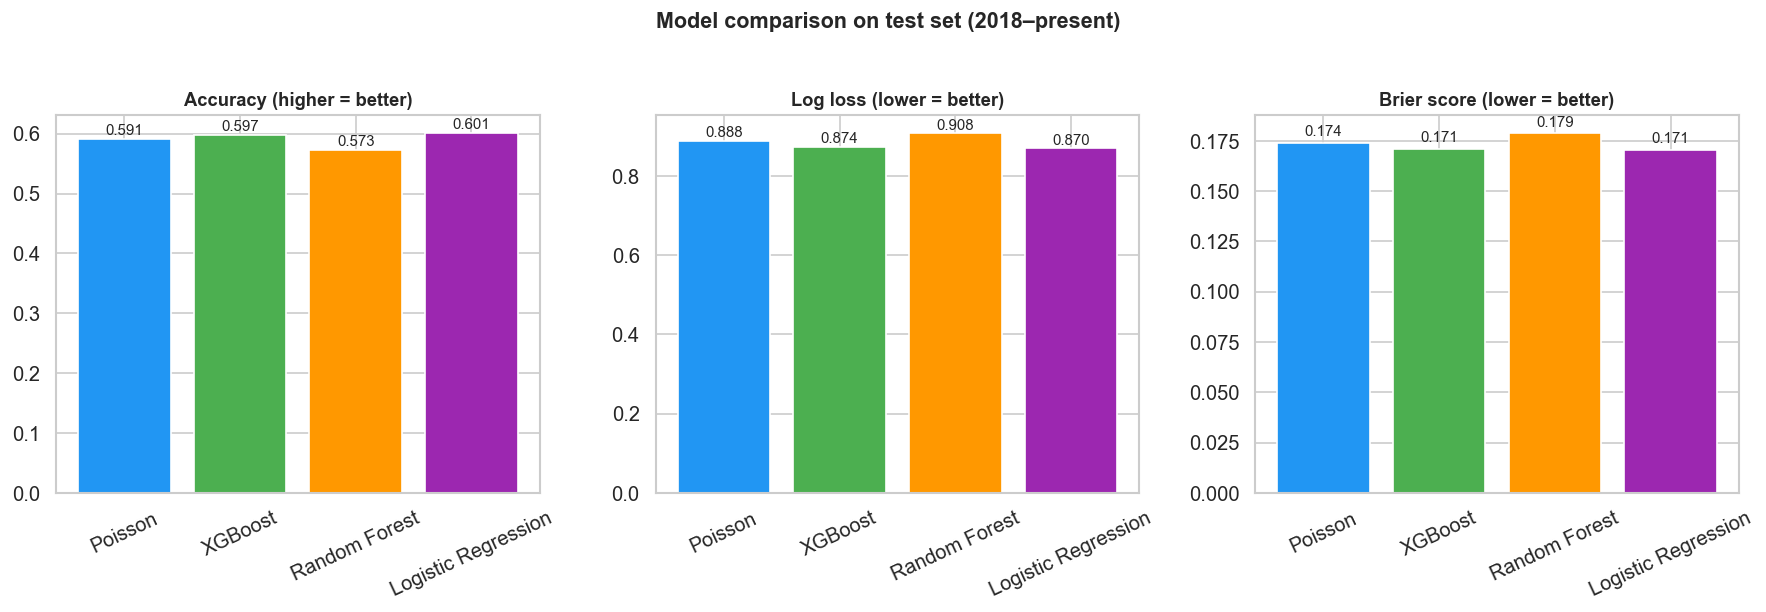

In [10]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['accuracy', 'log_loss', 'brier_score']
titles  = ['Accuracy (higher = better)', 'Log loss (lower = better)', 'Brier score (lower = better)']
colors  = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for ax, metric, title in zip(axes, metrics, titles):
    vals = results_df[metric]
    bars = ax.bar(vals.index, vals.values, color=colors, edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model comparison on test set (2018–present)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'model_comparison.png'), bbox_inches='tight')
plt.show()


## 5. Cross-validation (train set)

In [11]:
cv_results = []
for name, model in [
    ('XGBoost',             build_xgboost()),
    ('Random Forest',       build_random_forest()),
    ('Logistic Regression', build_logistic()),
]:
    cv_results.append(cross_validate_model(name, model, X_train, y_train, n_splits=5))

cv_df = pd.DataFrame(cv_results).set_index('model')
print()
print(cv_df.round(4).to_string())


2026-06-12 01:06:44 [INFO] src.model: XGBoost               CV acc=0.574 ± 0.011
2026-06-12 01:07:11 [INFO] src.model: Random Forest         CV acc=0.534 ± 0.018
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will 


                     cv_mean  cv_std
model                               
XGBoost               0.5737  0.0108
Random Forest         0.5338  0.0181
Logistic Regression   0.5736  0.0114


## 6. Build & evaluate ensemble

In [12]:
ensemble = EnsembleModel(
    poisson_model=poisson_model,
    xgb_model=xgb_model,
    rf_model=rf_model,
    lr_model=lr_model,
    weights=(0.35, 0.30, 0.20, 0.15),
)

ens_proba = ensemble.predict_proba(X_test)
ens_pred  = ensemble.predict(X_test)

ens_metrics = evaluate_model('Ensemble', y_test.values, ens_pred, ens_proba)
print()
print(f"Ensemble accuracy:   {ens_metrics['accuracy']:.4f}")
print(f"Ensemble log loss:   {ens_metrics['log_loss']:.4f}")
print(f"Ensemble brier:      {ens_metrics['brier_score']:.4f}")


2026-06-12 01:07:15 [INFO] src.model: Ensemble              acc=0.599  log_loss=0.873  brier=0.171



Ensemble accuracy:   0.5989
Ensemble log loss:   0.8727
Ensemble brier:      0.1709


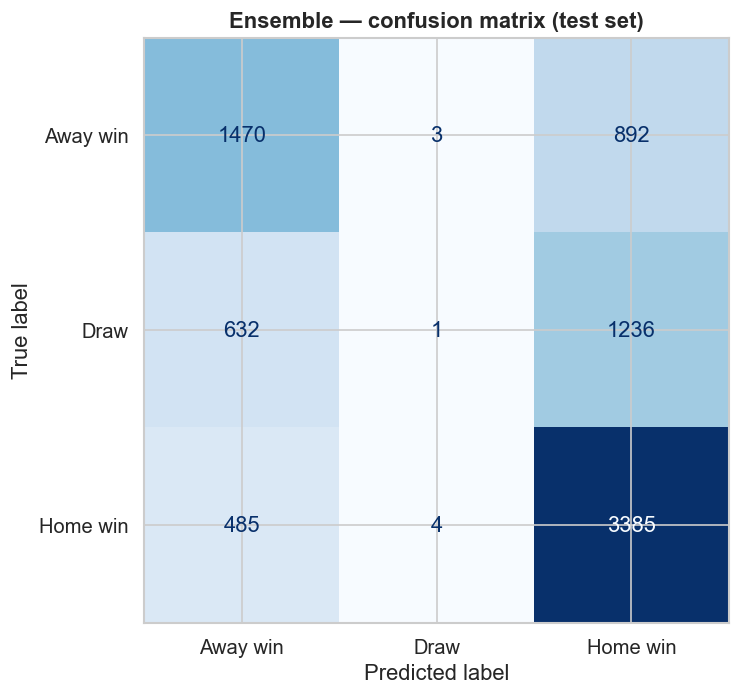

In [13]:
# Confusion matrix for ensemble
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test.values, ens_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Away win', 'Draw', 'Home win']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Ensemble — confusion matrix (test set)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'ensemble_confusion_matrix.png'), bbox_inches='tight')
plt.show()


## 7. Feature importance (XGBoost)

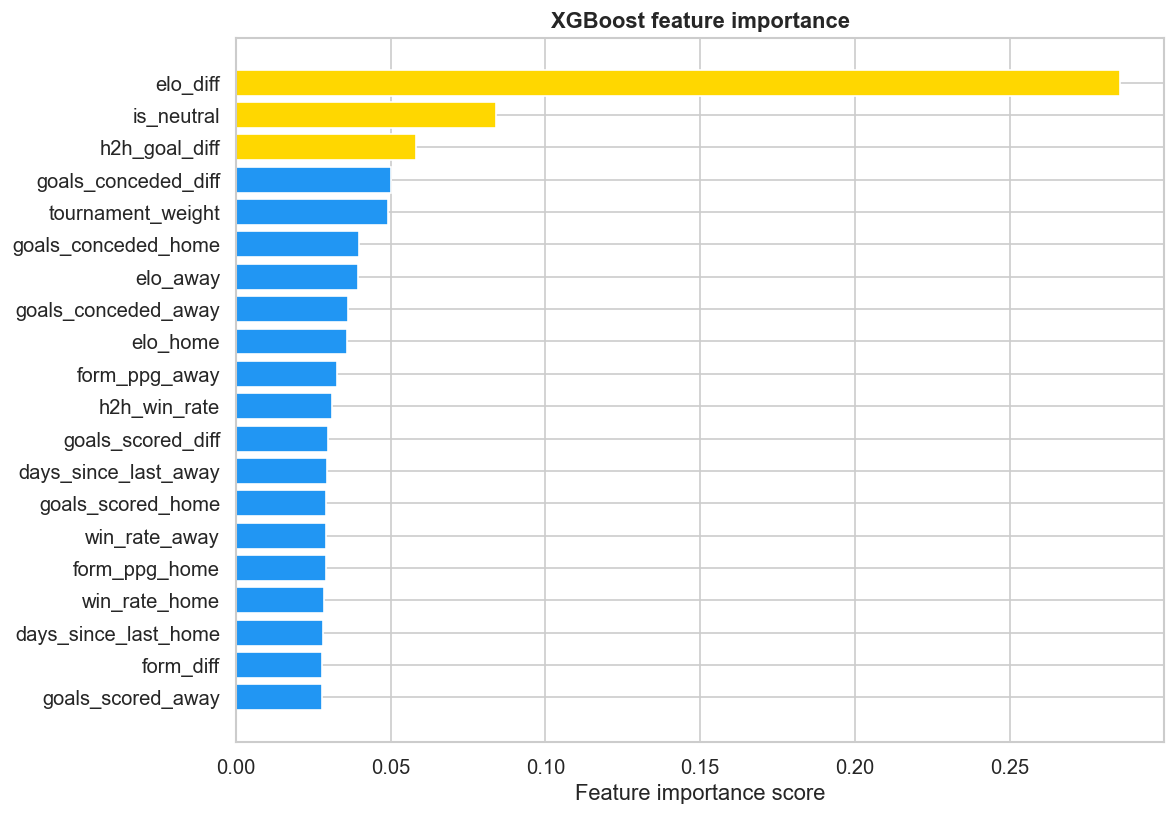

Top 5 most important features:
elo_diff               0.2857
is_neutral             0.0841
h2h_goal_diff          0.0580
goals_conceded_diff    0.0500
tournament_weight      0.0491


In [14]:
importances = xgb_model.named_steps['clf'].feature_importances_
feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#FFD700' if i < 3 else '#2196F3' for i in range(len(feat_imp))]
ax.barh(feat_imp.index[::-1], feat_imp.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel('Feature importance score')
ax.set_title('XGBoost feature importance', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'feature_importance.png'), bbox_inches='tight')
plt.show()

print('Top 5 most important features:')
print(feat_imp.head(5).round(4).to_string())


## 8. Probability calibration check

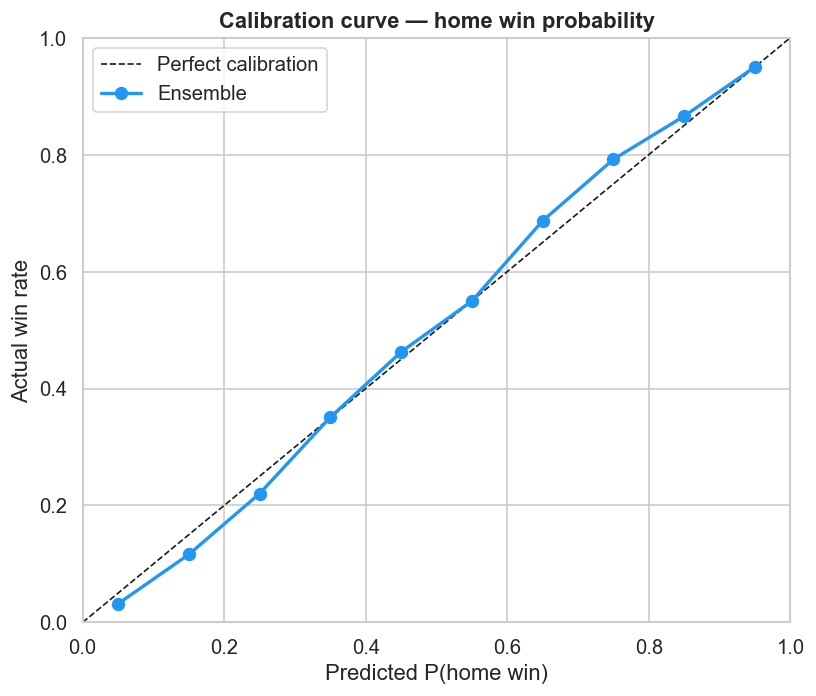

In [15]:
# Are our probabilities well-calibrated?
# Plot predicted P(home win) vs actual win rate in probability buckets

home_win_proba = ens_proba[:, 2]
actual         = (y_test.values == 2).astype(int)

bins = np.linspace(0, 1, 11)
bin_centers, actual_rates = [], []

for i in range(len(bins) - 1):
    mask = (home_win_proba >= bins[i]) & (home_win_proba < bins[i+1])
    if mask.sum() > 5:
        bin_centers.append((bins[i] + bins[i+1]) / 2)
        actual_rates.append(actual[mask].mean())

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1], [0,1], 'k--', lw=1, label='Perfect calibration')
ax.plot(bin_centers, actual_rates, 'o-', color='#2196F3', lw=2, ms=7, label='Ensemble')
ax.set_xlabel('Predicted P(home win)')
ax.set_ylabel('Actual win rate')
ax.set_title('Calibration curve — home win probability', fontweight='bold')
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'calibration_curve.png'), bbox_inches='tight')
plt.show()


## 9. Save all models

In [16]:
import joblib

joblib.dump(poisson_model, os.path.join('..', 'models', 'poisson_model.pkl'))
joblib.dump(xgb_model,     os.path.join('..', 'models', 'xgb_model.pkl'))
joblib.dump(rf_model,      os.path.join('..', 'models', 'rf_model.pkl'))
joblib.dump(lr_model,      os.path.join('..', 'models', 'lr_model.pkl'))
joblib.dump(ensemble,      os.path.join('..', 'models', 'ensemble_model.pkl'))

print('All models saved to models/ ✓')
print()
print('Files:')
for f in os.listdir(os.path.join('..', 'models')):
    size = os.path.getsize(os.path.join('..', 'models', f)) / 1024
    print(f'  {f:30s}  {size:.0f} KB')


All models saved to models/ ✓

Files:
  xgb_model.pkl                   1927 KB
  poisson_model.pkl               4 KB
  lr_model.pkl                    3 KB
  ensemble_model.pkl              18713 KB
  rf_model.pkl                    16749 KB


## ✅ Model training complete

| Model | Role |
|---|---|
| Poisson | Predicts scorelines, theoretically grounded |
| XGBoost | Best single classifier, captures non-linear patterns |
| Random Forest | Strong ensemble member, robust to overfitting |
| Logistic Regression | Fast baseline, surprisingly competitive |
| **Ensemble** | **What we use for tournament simulation** |

**Next notebook → `04_simulation.ipynb`:** Load the ensemble and run 100,000 Monte Carlo simulations of the full World Cup bracket.
